<a href="https://colab.research.google.com/github/BardRimon/Study/blob/main/CV/HW2_ImageClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Домашняя работа №2

MobileNet-V2 (2018)

In [1]:
# ! pip install torchsummary


In [11]:
import torch
import torchvision.models as models

# Download the MobileNetV2 model with pre-trained weights
mobilenet_v2 = models.mobilenet_v2(weights='IMAGENET1K_V1')

# You can now use the 'mobilenet_v2' model for various tasks.
# For example, to see the model architecture:
# print(mobilenet_v2)

In [12]:
! pip install torchinfo
from torchinfo import summary
summary(mobilenet_v2, input_size=(1, 3, 224, 224))  # 1 - размер батча

Layer (type:depth-idx)                             Output Shape              Param #
MobileNetV2                                        [1, 1000]                 --
├─Sequential: 1-1                                  [1, 1280, 7, 7]           --
│    └─Conv2dNormActivation: 2-1                   [1, 32, 112, 112]         --
│    │    └─Conv2d: 3-1                            [1, 32, 112, 112]         864
│    │    └─BatchNorm2d: 3-2                       [1, 32, 112, 112]         64
│    │    └─ReLU6: 3-3                             [1, 32, 112, 112]         --
│    └─InvertedResidual: 2-2                       [1, 16, 112, 112]         --
│    │    └─Sequential: 3-4                        [1, 16, 112, 112]         896
│    └─InvertedResidual: 2-3                       [1, 24, 56, 56]           --
│    │    └─Sequential: 3-5                        [1, 24, 56, 56]           5,136
│    └─InvertedResidual: 2-4                       [1, 24, 56, 56]           --
│    │    └─Sequential: 3-6   

Информация о модели взята от сюда: https://arxiv.org/pdf/1801.04381#page=3.08


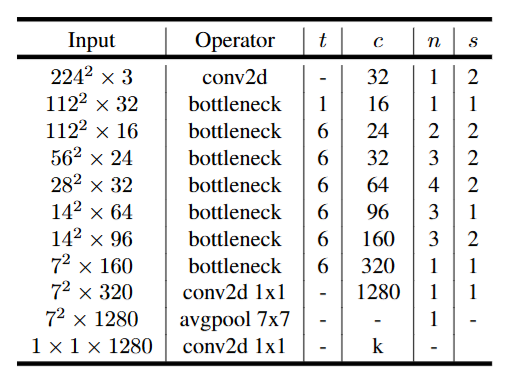

Возможные полезные штучки
https://github.com/tonylins/pytorch-mobilenet-v2/blob/master/README.md

In [13]:
import torch
import torch.nn as nn

class InvertedResidual(nn.Module):
    def __init__(self, in_channels, out_channels, stride, expand_ratio):
        super(InvertedResidual, self).__init__()
        self.stride = stride
        hidden_dim = int(round(in_channels * expand_ratio))
        self.use_res_connect = self.stride == 1 and in_channels == out_channels

        layers = []
        if expand_ratio != 1:
            # Расширяющая свертка 1x1 (pointwise)
            layers.append(nn.Conv2d(in_channels, hidden_dim, kernel_size=1, stride=1, padding=0, bias=False))
            layers.append(nn.BatchNorm2d(hidden_dim))
            layers.append(nn.ReLU6(inplace=True))

        # Глубинная свертка 3x3 (depthwise)
        layers.extend([
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, stride=stride, padding=1, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU6(inplace=True),
        ])

        # Сжимающая свертка 1x1 (pointwise) с линейной активацией
        layers.extend([
            nn.Conv2d(hidden_dim, out_channels, kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(out_channels),
        ])

        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_res_connect:
            return x + self.conv(x)
        else:
            return self.conv(x)


class MobileNetV2(nn.Module):
    def __init__(self, num_classes=1000, width_mult=1.0):
        super(MobileNetV2, self).__init__()
        block = InvertedResidual
        input_channel = 32
        last_channel = 1280

        # Таблица конфигурации для блоков MobileNetV2
        # t: expand_ratio, c: out_channels, n: num_blocks, s: stride
        inverted_residual_setting = [
            [1, 16, 1, 1],
            [6, 24, 2, 2],
            [6, 32, 3, 2],
            [6, 64, 4, 2],
            [6, 96, 3, 1],
            [6, 160, 3, 2],
            [6, 320, 1, 1],
        ]

        # Начальный сверточный слой
        input_channel = int(input_channel * width_mult)
        self.last_channel = int(last_channel * max(1.0, width_mult))
        features = [
            nn.Conv2d(3, input_channel, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(input_channel),
            nn.ReLU6(inplace=True),
        ]

        # Создание последовательности инвертированных остаточных блоков
        for t, c, n, s in inverted_residual_setting:
            output_channel = int(c * width_mult)
            for i in range(n):
                stride = s if i == 0 else 1
                features.append(block(input_channel, output_channel, stride, expand_ratio=t))
                input_channel = output_channel

        # Последние слои перед классификацией
        features.append(nn.Conv2d(input_channel, self.last_channel, kernel_size=1, stride=1, padding=0, bias=False))
        features.append(nn.BatchNorm2d(self.last_channel))
        features.append(nn.ReLU6(inplace=True))

        self.features = nn.Sequential(*features)

        # Классификационная часть
        self.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(self.last_channel, num_classes),
        )

        # Инициализация весов
        self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = x.mean([2, 3])  # Глобальный усредняющий пулинг
        x = self.classifier(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)

# Пример создания модели

model = MobileNetV2(num_classes=3)
# print(model)

#     # Пример входного тензора
#     input_tensor = torch.randn(1, 3, 224, 224)
#     output = model(input_tensor)
#     print("Размер выходного тензора:", output.shape)

In [14]:
summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
MobileNetV2                              [1, 3]                    --
├─Sequential: 1-1                        [1, 1280, 7, 7]           --
│    └─Conv2d: 2-1                       [1, 32, 112, 112]         864
│    └─BatchNorm2d: 2-2                  [1, 32, 112, 112]         64
│    └─ReLU6: 2-3                        [1, 32, 112, 112]         --
│    └─InvertedResidual: 2-4             [1, 16, 112, 112]         --
│    │    └─Sequential: 3-1              [1, 16, 112, 112]         896
│    └─InvertedResidual: 2-5             [1, 24, 56, 56]           --
│    │    └─Sequential: 3-2              [1, 24, 56, 56]           5,136
│    └─InvertedResidual: 2-6             [1, 24, 56, 56]           --
│    │    └─Sequential: 3-3              [1, 24, 56, 56]           8,832
│    └─InvertedResidual: 2-7             [1, 32, 28, 28]           --
│    │    └─Sequential: 3-4              [1, 32, 28, 28]           10,000
│  

Но обучать 1000 классов очень займёт слишком большое время, так что изменим модель, чтобы она классифицировала 3 класса

In [15]:
# Установка kaggle и импорт необходимых модулей
from google.colab import drive
import os

# Монтируем Google Drive в Colab
drive.mount('/content/drive')

# Путь к kaggle.json на Google Drive (укажите путь к своему файлу)
kaggle_json_path = '/content/drive/MyDrive/Colab Notebooks/kaggle.json' ##### ВОТ ТУТ МЕНЯТЬ ПУТЬ К KAGGLE.JSON

# Создаем папку .kaggle в домашней директории и копируем файл туда
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
!cp "{kaggle_json_path}" ~/.kaggle/kaggle.json

# Меняем права доступа к файлу
!chmod 600 ~/.kaggle/kaggle.json

# Проверяем, что всё работает, показывая список датасетов (можно потом заменить командой скачивания)
!kaggle datasets list

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ref                                                            title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
ahmeduzaki/global-earthquake-tsunami-risk-assessment-dataset   Global Earthquake-Tsunami Risk Assessment Dataset       16151  2025-10-01 16:35:53.273000          15785        537  1.0              
jockeroika/life-style-data                                     Life Style Data                                       3995645  2025-10-14 13:50:45.303000          18539        375  0.8235294        
jaderz/hospital-beds-management                                Hospital Beds Ma

In [18]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sanikamal/rock-paper-scissors-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'rock-paper-scissors-dataset' dataset.
Path to dataset files: /kaggle/input/rock-paper-scissors-dataset


In [20]:
import os
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image

# --- 1. Определение путей и параметров ---

# Основной путь к датасету
# BASE_PATH = '/root/.cache/kagglehub/datasets/sanikamal/rock-paper-scissors-dataset/versions/1/Rock-Paper-Scissors'
BASE_PATH = '/kaggle/input/rock-paper-scissors-dataset/Rock-Paper-Scissors'
# Пути к папкам с данными
# Нам больше не нужна отдельная папка для валидации
train_dir = os.path.join(BASE_PATH, 'train')
test_dir = os.path.join(BASE_PATH, 'test')

# Параметры
BATCH_SIZE = 32
IMG_SIZE = (224, 224) # Размер изображений для MobileNetV2
VALIDATION_SPLIT = 0.2 # Доля данных, которая пойдет на валидацию (20%)


# --- 2. Создание трансформаций ---

# Трансформации для обучающего набора данных (с аугментацией)
train_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomRotation(30),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Трансформации для валидационного и тестового наборов (без аугментации)
val_test_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# --- 3. Создание кастомного класса Dataset (остается без изменений) ---

class RockPaperScissorsDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.class_to_idx = {'rock': 0, 'paper': 1, 'scissors': 2}
        self.idx_to_class = {v: k for k, v in self.class_to_idx.items()}
        self.samples = self._make_dataset()

    def _make_dataset(self):
        samples = []
        for class_name in sorted(self.class_to_idx.keys()):
            class_dir = os.path.join(self.root_dir, class_name)
            if not os.path.isdir(class_dir):
                continue

            class_idx = self.class_to_idx[class_name]
            for filename in os.listdir(class_dir):
                if filename.endswith(('.png', '.jpg', '.jpeg')):
                    path = os.path.join(class_dir, filename)
                    item = (path, class_idx)
                    samples.append(item)
        return samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

# --- 4. Создание и разделение датасетов ---

# Сначала создаем один большой "тренировочный" датасет
# Важно: пока что применяем к нему train_transforms
full_train_dataset = RockPaperScissorsDataset(root_dir=train_dir, transform=train_transforms)

# Рассчитываем размеры для разделения
total_size = len(full_train_dataset)
val_size = int(total_size * VALIDATION_SPLIT)
train_size = total_size - val_size

# Разделяем датасет на обучающий и валидационный
# torch.manual_seed для воспроизводимости разделения
torch.manual_seed(42)
train_subset, val_subset = random_split(full_train_dataset, [train_size, val_size])

# ВАЖНО: для валидационного набора данных нужно использовать трансформации без аугментации.
# Мы обращаемся к внутреннему датасету подмножества и меняем его свойство transform.
val_subset.dataset.transform = val_test_transforms

# Создаем тестовый датасет как и раньше
test_dataset = RockPaperScissorsDataset(root_dir=test_dir, transform=val_test_transforms)


# --- 5. Создание DataLoader'ов ---

# Создаем загрузчики из наших новых подмножеств (subset)
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)



print(f"Общий размер исходного обучающего набора: {len(full_train_dataset)}")
print("-" * 30)
print(f"Размер нового обучающего набора (80%): {len(train_subset)}")
print(f"Размер нового валидационного набора (20%): {len(val_subset)}")
print(f"Размер тестового набора: {len(test_dataset)}")
print("-" * 30)

# Получим по одному батчу для проверки
train_images, train_labels = next(iter(train_loader))
val_images, val_labels = next(iter(val_loader))

print(f"Размер батча из train_loader: {train_images.shape}")
print(f"Размер батча из val_loader: {val_images.shape}")
print(f"Классы: {full_train_dataset.class_to_idx}")


Общий размер исходного обучающего набора: 2520
------------------------------
Размер нового обучающего набора (80%): 2016
Размер нового валидационного набора (20%): 504
Размер тестового набора: 372
------------------------------
Размер батча из train_loader: torch.Size([32, 3, 224, 224])
Размер батча из val_loader: torch.Size([32, 3, 224, 224])
Классы: {'rock': 0, 'paper': 1, 'scissors': 2}


Анализ распределения классов:

--- Папка: train ---
  paper: 840 изображений
  rock: 840 изображений
  scissors: 840 изображений
Всего в папке train: 2520 изображений

--- Папка: test ---
  paper: 124 изображений
  rock: 124 изображений
  scissors: 124 изображений
Всего в папке test: 372 изображений

Сводная таблица распределения классов:


,train,test
paper,840,124
rock,840,124
scissors,840,124


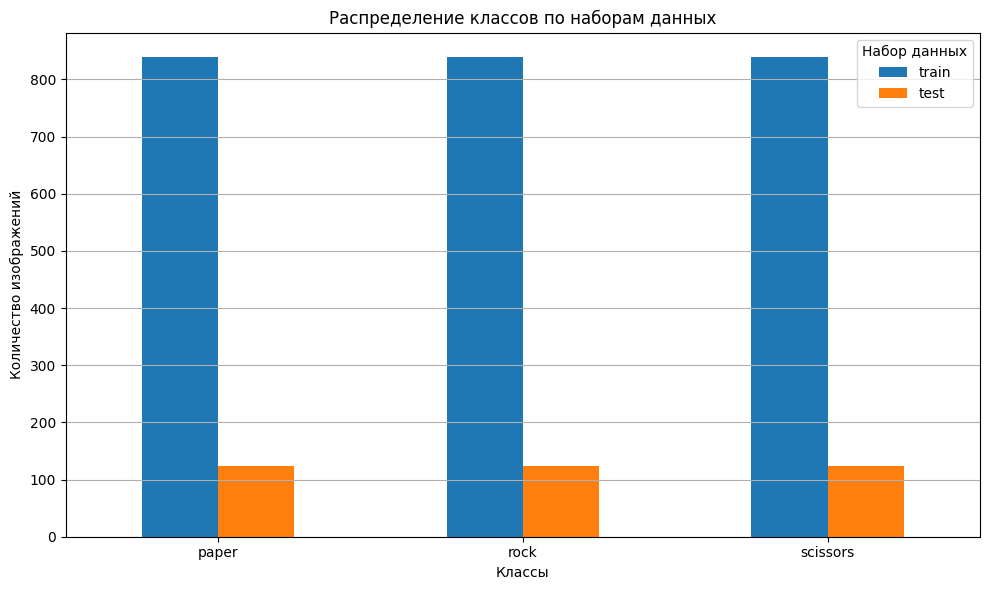

In [34]:
import os
import matplotlib.pyplot as plt
import pandas as pd

BASE_PATH = '/kaggle/input/rock-paper-scissors-dataset/Rock-Paper-Scissors'


dirs_to_analyze = ['train', 'test']

data = {}

print("Анализ распределения классов:")
for dir_name in dirs_to_analyze:
    dir_path = os.path.join(BASE_PATH, dir_name)
    if os.path.isdir(dir_path):
        print(f"\n--- Папка: {dir_name} ---")
        class_counts = {}
        total_in_dir = 0
        for class_name in sorted(os.listdir(dir_path)):
            class_dir = os.path.join(dir_path, class_name)
            if os.path.isdir(class_dir):
                num_images = len([f for f in os.listdir(class_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])
                class_counts[class_name] = num_images
                total_in_dir += num_images
                print(f"  {class_name}: {num_images} изображений")
        print(f"Всего в папке {dir_name}: {total_in_dir} изображений")
        data[dir_name] = class_counts
    else:
        print(f"\n--- Папка: {dir_name} не найдена ---")

# Создание DataFrame для удобного отображения и построения графиков
df = pd.DataFrame(data)
print("\nСводная таблица распределения классов:")
display(df)

# Визуализация распределения классов (гистограмма)
if not df.empty:
    df.plot(kind='bar', figsize=(10, 6))
    plt.title('Распределение классов по наборам данных')
    plt.xlabel('Классы')
    plt.ylabel('Количество изображений')
    plt.xticks(rotation=0)
    plt.legend(title='Набор данных')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

Название файла: scissors-hires1.png


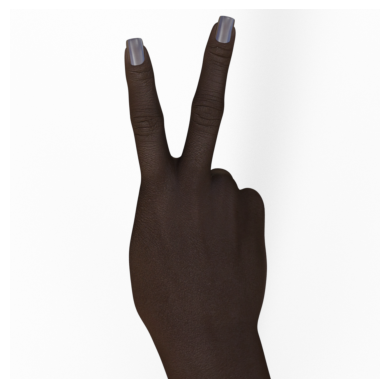

In [35]:
from PIL import Image
import matplotlib.pyplot as plt
import os

image_path = '/kaggle/input/rock-paper-scissors-dataset/Rock-Paper-Scissors/validation/scissors-hires1.png'

# Открываем изображение
try:
    img = Image.open(image_path)

    # Выводим название файла
    print(f"Название файла: {os.path.basename(image_path)}")

    # Отображаем изображение
    plt.imshow(img)
    plt.axis('off') # Отключаем оси
    plt.show()

except FileNotFoundError:
    print(f"Ошибка: Файл не найден по пути {image_path}")
except Exception as e:
    print(f"Произошла ошибка при открытии или отображении изображения: {e}")

Используемое устройство: cuda

Начало обучения...

--- Эпоха 1/4 ---


Eval: 100%|██████████| 16/16 [00:02<00:00,  6.19it/s, acc=0.3611, loss=3.27]



Результаты эпохи 1:
  Train Loss: 0.2850, Train Acc: 0.8785
  Val Loss:   3.6694, Val Acc:   0.3611

--- Эпоха 2/4 ---


Eval: 100%|██████████| 16/16 [00:02<00:00,  6.31it/s, acc=0.9960, loss=0.00386]



Результаты эпохи 2:
  Train Loss: 0.0274, Train Acc: 0.9916
  Val Loss:   0.0145, Val Acc:   0.9960

--- Эпоха 3/4 ---


Eval: 100%|██████████| 16/16 [00:02<00:00,  6.26it/s, acc=1.0000, loss=0.0061]



Результаты эпохи 3:
  Train Loss: 0.0035, Train Acc: 0.9995
  Val Loss:   0.0031, Val Acc:   1.0000

--- Эпоха 4/4 ---


Eval: 100%|██████████| 16/16 [00:02<00:00,  6.23it/s, acc=0.8135, loss=0.619]



Результаты эпохи 4:
  Train Loss: 0.0103, Train Acc: 0.9970
  Val Loss:   0.5696, Val Acc:   0.8135

Обучение завершено!


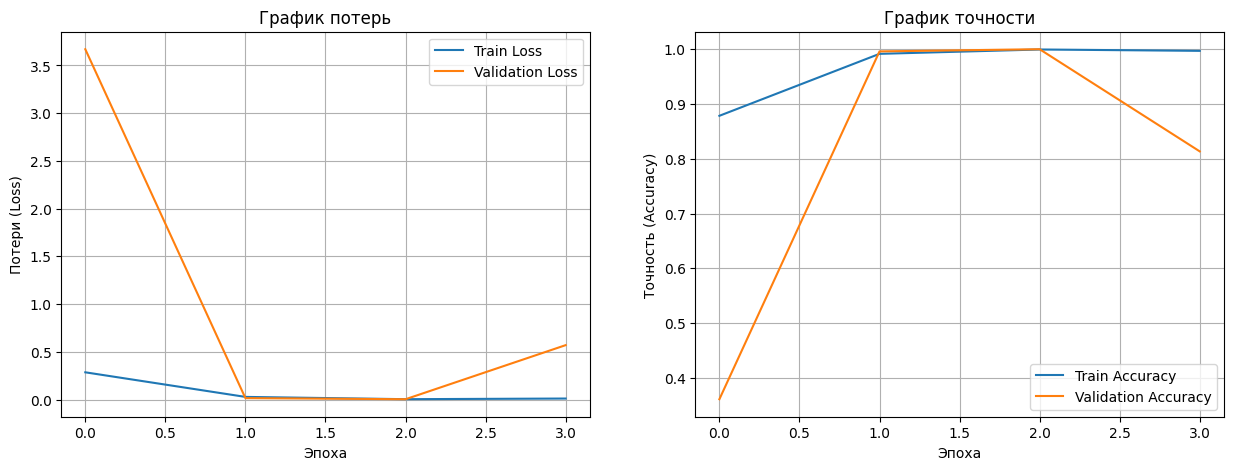


Начало финальной оценки на тестовых данных...


Eval: 100%|██████████| 12/12 [00:02<00:00,  4.46it/s, acc=0.8011, loss=1.39]


Результаты на тестовом наборе:
  Test Loss: 0.6593
  Test Accuracy: 0.8011 (80.11%)


In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- 1. Настройка ---

# Выбираем устройство для вычислений (GPU, если доступен, иначе CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

# Инициализируем модель и перемещаем её на выбранное устройство
# num_classes=3, так как у нас 3 класса: rock, paper, scissors
model = MobileNetV2(num_classes=3).to(device)

# Определяем функцию потерь. CrossEntropyLoss подходит для задач многоклассовой классификации.
criterion = nn.CrossEntropyLoss()

# Определяем оптимизатор. Adam - хороший выбор по умолчанию.
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Количество эпох обучения
NUM_EPOCHS = 4


# --- 2. Функция для одной эпохи обучения ---

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()  # Переводим модель в режим обучения
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # Используем tqdm для отображения прогресс-бара
    progress_bar = tqdm(dataloader, desc="Train")

    for inputs, labels in progress_bar:
        # Перемещаем данные на устройство
        inputs, labels = inputs.to(device), labels.to(device)

        # Обнуляем градиенты
        optimizer.zero_grad()

        # Прямой проход (forward pass)
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Обратный проход и оптимизация (backward pass)
        loss.backward()
        optimizer.step()

        # Собираем статистику
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct_predictions += torch.sum(preds == labels.data)
        total_samples += labels.size(0)

        # Обновляем информацию в прогресс-баре
        progress_bar.set_postfix(loss=loss.item(), acc=f"{correct_predictions/total_samples:.4f}")

    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions.double() / total_samples
    return epoch_loss, epoch_acc.item()


# --- 3. Функция для оценки модели ---

def evaluate(model, dataloader, criterion, device):
    model.eval()  # Переводим модель в режим оценки
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # Отключаем вычисление градиентов для экономии памяти и ускорения
    with torch.no_grad():
        progress_bar = tqdm(dataloader, desc="Eval")
        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_predictions += torch.sum(preds == labels.data)
            total_samples += labels.size(0)

            progress_bar.set_postfix(loss=loss.item(), acc=f"{correct_predictions/total_samples:.4f}")


    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions.double() / total_samples
    return epoch_loss, epoch_acc.item()


# --- 4. Основной цикл обучения и оценки ---

# Списки для хранения истории обучения
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

print("\nНачало обучения...")
for epoch in range(NUM_EPOCHS):
    print(f"\n--- Эпоха {epoch + 1}/{NUM_EPOCHS} ---")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"\nРезультаты эпохи {epoch + 1}:")
    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f}")

print("\nОбучение завершено!")


# --- 5. Визуализация результатов ---

def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # График потерь
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Validation Loss')
    ax1.set_xlabel('Эпоха')
    ax1.set_ylabel('Потери (Loss)')
    ax1.set_title('График потерь')
    ax1.legend()
    ax1.grid(True)

    # График точности
    ax2.plot(history['train_acc'], label='Train Accuracy')
    ax2.plot(history['val_acc'], label='Validation Accuracy')
    ax2.set_xlabel('Эпоха')
    ax2.set_ylabel('Точность (Accuracy)')
    ax2.set_title('График точности')
    ax2.legend()
    ax2.grid(True)

    plt.show()

plot_history(history)


# --- 6. Финальная проверка на тестовом наборе данных ---

print("\nНачало финальной оценки на тестовых данных...")
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"\nРезультаты на тестовом наборе:")
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

На 5 эпохах ничего не понятно, давайте обучать больше

Истинный класс образца: paper
Предсказанный класс модели: paper

Вероятности по классам:
  rock: 0.0000
  paper: 1.0000
  scissors: 0.0000


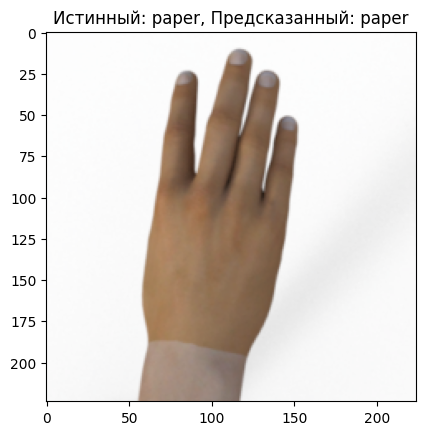

In [29]:

model.eval()

# Получаем один образец из train_loader
# Следующая строка получает первый батч из train_loader
images, labels = next(iter(test_loader)) # Изменил на test_loader, чтобы проанализировать misprediction на тесте

# Берем образец с индексом 10 из батча (это тот, где была ошибка в предыдущем запуске)
sample_image = images[10].unsqueeze(0).to(device) # Добавляем размерность батча и перемещаем на устройство
sample_label = labels[10].item() # Получаем истинный класс образца

# Выводим истинный класс
print(f"Истинный класс образца: {test_dataset.idx_to_class[sample_label]}")

# Отключаем вычисление градиентов для предсказания
with torch.no_grad():
    # Получаем предсказания модели (логиты)
    outputs = model(sample_image)

# Применяем softmax для получения вероятностей
probabilities = torch.softmax(outputs, dim=1)

# Получаем предсказанный класс (индекс с максимальной вероятностью)
_, predicted_idx = torch.max(outputs.data, 1)
predicted_label = predicted_idx.item()

# Выводим предсказанный класс
print(f"Предсказанный класс модели: {test_dataset.idx_to_class[predicted_label]}")

# Выводим вероятности для всех классов
print("\nВероятности по классам:")
for i, prob in enumerate(probabilities[0]):
    print(f"  {test_dataset.idx_to_class[i]}: {prob.item():.4f}")


# Визуализация образца (опционально, но полезно)
import matplotlib.pyplot as plt
import numpy as np

# Функция для отображения изображения
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

# Отображаем образец
imshow(images[10], title=f'Истинный: {test_dataset.idx_to_class[sample_label]}, Предсказанный: {test_dataset.idx_to_class[predicted_label]}')

Попробуем обучить модель большим числом эпох


Начало обучения...

--- Эпоха 1/10 ---


Eval: 100%|██████████| 16/16 [00:02<00:00,  6.19it/s, acc=0.7996, loss=0.461]



Результаты эпохи 1:
  Train Loss: 0.0375, Train Acc: 0.9871
  Val Loss:   0.6171, Val Acc:   0.7996

--- Эпоха 2/10 ---


Eval: 100%|██████████| 16/16 [00:02<00:00,  6.12it/s, acc=0.9980, loss=0.00598]



Результаты эпохи 2:
  Train Loss: 0.0125, Train Acc: 0.9950
  Val Loss:   0.0120, Val Acc:   0.9980

--- Эпоха 3/10 ---


...


Результаты эпохи 8:
  Train Loss: 0.0021, Train Acc: 0.9995
  Val Loss:   0.0003, Val Acc:   1.0000

--- Эпоха 9/10 ---


Eval: 100%|██████████| 16/16 [00:02<00:00,  6.05it/s, acc=1.0000, loss=3.79e-5]



Результаты эпохи 9:
  Train Loss: 0.0002, Train Acc: 1.0000
  Val Loss:   0.0001, Val Acc:   1.0000

--- Эпоха 10/10 ---


Eval: 100%|██████████| 16/16 [00:02<00:00,  6.21it/s, acc=1.0000, loss=1.62e-5]



Результаты эпохи 10:
  Train Loss: 0.0001, Train Acc: 1.0000
  Val Loss:   0.0000, Val Acc:   1.0000

Обучение завершено!


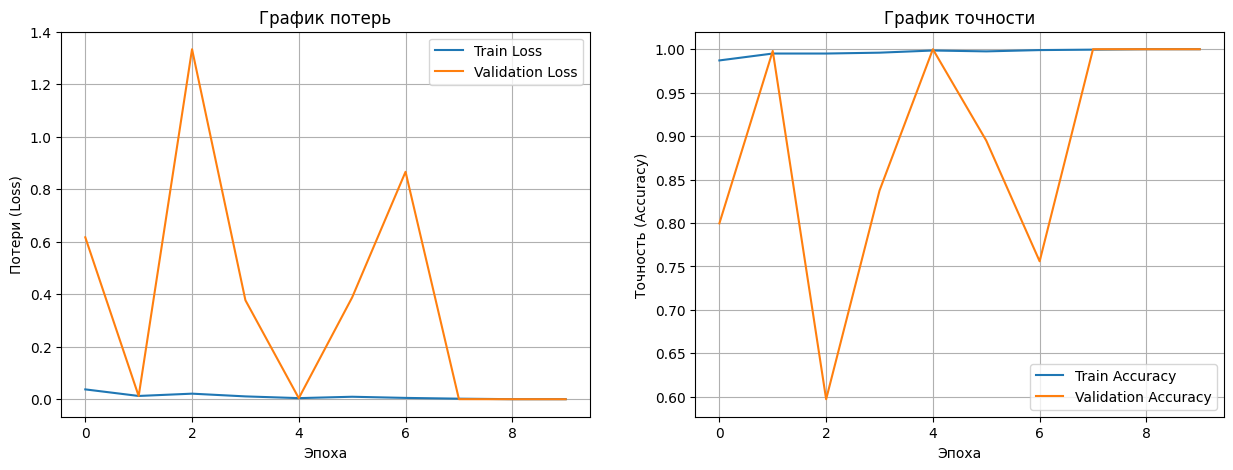


Начало финальной оценки на тестовых данных...


Eval: 100%|██████████| 12/12 [00:03<00:00,  3.91it/s, acc=0.9382, loss=0.000137]


Результаты на тестовом наборе:
  Test Loss: 0.2529
  Test Accuracy: 0.9382 (93.82%)


In [30]:
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}
NUM_EPOCHS = 10
print("\nНачало обучения...")
for epoch in range(NUM_EPOCHS):
    print(f"\n--- Эпоха {epoch + 1}/{NUM_EPOCHS} ---")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"\nРезультаты эпохи {epoch + 1}:")
    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f}")

print("\nОбучение завершено!")


# --- 5. Визуализация результатов ---

def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # График потерь
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Validation Loss')
    ax1.set_xlabel('Эпоха')
    ax1.set_ylabel('Потери (Loss)')
    ax1.set_title('График потерь')
    ax1.legend()
    ax1.grid(True)

    # График точности
    ax2.plot(history['train_acc'], label='Train Accuracy')
    ax2.plot(history['val_acc'], label='Validation Accuracy')
    ax2.set_xlabel('Эпоха')
    ax2.set_ylabel('Точность (Accuracy)')
    ax2.set_title('График точности')
    ax2.legend()
    ax2.grid(True)

    plt.show()

plot_history(history)


# --- 6. Финальная проверка на тестовом наборе данных ---

print("\nНачало финальной оценки на тестовых данных...")
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"\nРезультаты на тестовом наборе:")
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

Истинный класс образца: paper
Предсказанный класс модели: scissors

Вероятности по классам:
  rock: 0.0580
  paper: 0.3468
  scissors: 0.5953


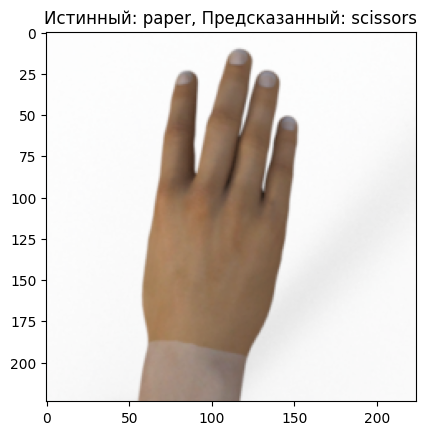

In [31]:
model.eval()

# Получаем один образец из train_loader
# Следующая строка получает первый батч из train_loader
images, labels = next(iter(test_loader)) # Изменил на test_loader, чтобы проанализировать misprediction на тесте

# Берем образец с индексом 10 из батча (это тот, где была ошибка в предыдущем запуске)
sample_image = images[10].unsqueeze(0).to(device) # Добавляем размерность батча и перемещаем на устройство
sample_label = labels[10].item() # Получаем истинный класс образца

# Выводим истинный класс
print(f"Истинный класс образца: {test_dataset.idx_to_class[sample_label]}")

# Отключаем вычисление градиентов для предсказания
with torch.no_grad():
    # Получаем предсказания модели (логиты)
    outputs = model(sample_image)

# Применяем softmax для получения вероятностей
probabilities = torch.softmax(outputs, dim=1)

# Получаем предсказанный класс (индекс с максимальной вероятностью)
_, predicted_idx = torch.max(outputs.data, 1)
predicted_label = predicted_idx.item()

# Выводим предсказанный класс
print(f"Предсказанный класс модели: {test_dataset.idx_to_class[predicted_label]}")

# Выводим вероятности для всех классов
print("\nВероятности по классам:")
for i, prob in enumerate(probabilities[0]):
    print(f"  {test_dataset.idx_to_class[i]}: {prob.item():.4f}")


# Визуализация образца (опционально, но полезно)
import matplotlib.pyplot as plt
import numpy as np

# Функция для отображения изображения
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

# Отображаем образец
imshow(images[10], title=f'Истинный: {test_dataset.idx_to_class[sample_label]}, Предсказанный: {test_dataset.idx_to_class[predicted_label]}')

Можно увидеть, что модель перестала правильно определять класс
Причина может быть в переобучении модели